# Libraries

In [8]:
%load_ext tensorboard

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorboard as tb

from scipy.stats import f_oneway, ttest_ind

import warnings
warnings.filterwarnings("ignore")

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


# Tensorboard Download

In [40]:
%tensorboard --logdir="logs/time-tune/model8"

Reusing TensorBoard on port 6006 (pid 19675), started 0:29:07 ago. (Use '!kill 19675' to kill it.)

# Auxilary Functions

In [ ]:
def grouper(df):
    return df.groupby(
    ["emb_units",	"lstm_units",	"dropout",	"l_rate"],
     as_index=False).agg(
        {"sparse_categorical_accuracy":["mean", "std"]})
tune_df = pd.DataFrame(index=["emb_units",	"lstm_units", "dropout",
                              "l_rate", "acc_mean", "acc_std"])

# Tuning Results

In [33]:
r = pd.read_csv(
    "random_results.csv")

In [ ]:
m1 = pd.read_csv(
    "https://github.com/ibrahimerdem/application_storage/raw/main/time-basis-tuning/model1tune1.csv")

m1 = m1.sort_values(["emb_units", "lstm_units", "dropout",
                     "l_rate", "replication"], ignore_index=True)

m2 = pd.read_csv(
    "https://github.com/ibrahimerdem/application_storage/raw/main/time-basis-tuning/model2tune1.csv")

m2 = m2.sort_values(["emb_units", "lstm_units", "dropout",
                     "l_rate", "replication"], ignore_index=True)

m3 = pd.read_csv(
    "https://github.com/ibrahimerdem/application_storage/raw/main/time-basis-tuning/model3tune1.csv")

m3 = m3.sort_values(["emb_units", "lstm_units", "dropout",
                     "l_rate", "replication"], ignore_index=True)

m4 = pd.read_csv(
    "https://github.com/ibrahimerdem/application_storage/raw/main/time-basis-tuning/model4tune1.csv")

m4 = m4.sort_values(["emb_units", "lstm_units", "dropout",
                     "l_rate", "replication"], ignore_index=True)

m5 = pd.read_csv(
    "https://github.com/ibrahimerdem/application_storage/raw/main/time-basis-tuning/model5tune1.csv")

m5 = m5.sort_values(["emb_units", "lstm_units", "dropout",
                     "l_rate", "replication"], ignore_index=True)

m6 = pd.read_csv(
    "https://github.com/ibrahimerdem/application_storage/raw/main/time-basis-tuning/model6tune1.csv")

m6 = m6.sort_values(["emb_units", "lstm_units", "dropout",
                     "l_rate", "replication"], ignore_index=True)

m7 = pd.read_csv(
    "https://github.com/ibrahimerdem/application_storage/raw/main/time-basis-tuning/model7tune1.csv")

m7 = m7.sort_values(["emb_units", "lstm_units", "dropout",
                     "l_rate", "replication"], ignore_index=True)

In [34]:
r

,model_num,rnn_style,emb_units,rnn_units,drop_rate,l_rate,replication,accuracy
0,1.0,lstm,128.0,400.0,0.8,0.001,1.0,0.296229
1,1.0,lstm,96.0,500.0,0.8,0.001,1.0,0.287867
2,1.0,lstm,64.0,600.0,0.6,0.001,1.0,0.262346
3,1.0,lstm,32.0,400.0,0.8,0.001,2.0,0.305548
4,1.0,lstm,64.0,200.0,0.6,0.001,2.0,0.289086
...,...,...,...,...,...,...,...,...
763,8.0,lstm,64.0,200.0,0.6,0.001,1.0,0.301716
764,8.0,lstm,32.0,100.0,0.6,0.001,1.0,0.317829
765,8.0,lstm,64.0,200.0,0.6,0.001,2.0,0.301193
766,8.0,lstm,128.0,400.0,0.8,0.001,2.0,0.336121


In [14]:
r = r.sort_values(["emb_units", "rnn_units", "drop_out",
                   "l_rate", "replication"], ignore_index=True)

KeyError: 'emb_units'

## Top5

In [ ]:
m1g = grouper(m1)
m1top = m1g.sort_values(("sparse_categorical_accuracy", "mean"),
                        ascending=False,
                        ignore_index=True).head(5)
m1top

emb_units lstm_units dropout l_rate sparse_categorical_accuracy          
                                                             mean       std
0      96.0      100.0     0.8  0.001                    0.387984  0.002219
1     128.0      100.0     0.8  0.001                    0.385795  0.013883
2      96.0      200.0     0.8  0.001                    0.384176  0.003090
3     128.0      300.0     0.8  0.001                    0.383700  0.007171
4      96.0      100.0     0.6  0.001                    0.379987  0.004483

In [ ]:
m2g = grouper(m2)
m2top = m2g.sort_values(("sparse_categorical_accuracy", "mean"),
                        ascending=False,
                        ignore_index=True).head(5)
m2top

emb_units lstm_units dropout l_rate sparse_categorical_accuracy          
                                                             mean       std
0     128.0      200.0     0.8  0.001                    0.397982  0.001624
1      64.0      200.0     0.8  0.001                    0.394459  0.001784
2     128.0      300.0     0.8  0.001                    0.392840  0.001944
3     128.0      100.0     0.8  0.001                    0.391698  0.005300
4      64.0      100.0     0.6  0.001                    0.390650  0.008126

In [ ]:
m3g = grouper(m3)
m3top = m3g.sort_values(("sparse_categorical_accuracy", "mean"),
                        ascending=False,
                        ignore_index=True).head(5)
m3top

emb_units lstm_units dropout l_rate sparse_categorical_accuracy          
                                                             mean       std
0     128.0      200.0     0.8  0.001                    0.394078  0.000660
1      64.0      100.0     0.8  0.001                    0.393507  0.004884
2      32.0      200.0     0.8  0.001                    0.392269  0.003443
3      32.0      300.0     0.8  0.001                    0.392269  0.007472
4      96.0      200.0     0.8  0.001                    0.391983  0.009016

In [ ]:
m4g = grouper(m4)
m4top = m4g.sort_values(("sparse_categorical_accuracy", "mean"),
                        ascending=False,
                        ignore_index=True).head(5)
m4top

emb_units lstm_units dropout l_rate sparse_categorical_accuracy          
                                                             mean       std
0     128.0      200.0     0.8  0.001                    0.401314  0.006979
1      96.0      200.0     0.8  0.001                    0.401123  0.010457
2     128.0      300.0     0.8  0.001                    0.393983  0.005772
3      64.0      200.0     0.8  0.001                    0.393887  0.004489
4      96.0      100.0     0.6  0.001                    0.393792  0.001573

In [ ]:
m5g = grouper(m5)
m5top = m5g.sort_values(("sparse_categorical_accuracy", "mean"),
                        ascending=False,
                        ignore_index=True).head(5)
m5top

emb_units lstm_units dropout l_rate sparse_categorical_accuracy          
                                                             mean       std
0      96.0      100.0     0.8  0.001                    0.398458  0.006381
1     128.0      200.0     0.8  0.001                    0.397982  0.002700
2      64.0      200.0     0.8  0.001                    0.394078  0.003210
3      96.0      200.0     0.8  0.001                    0.393126  0.002291
4      32.0      200.0     0.8  0.001                    0.392650  0.006767

In [ ]:
m6g = grouper(m6)
m6top = m6g.sort_values(("sparse_categorical_accuracy", "mean"),
                        ascending=False,
                        ignore_index=True).head(5)
m6top

emb_units lstm_units dropout l_rate sparse_categorical_accuracy          
                                                             mean       std
0      64.0      200.0     0.8  0.001                    0.395316  0.002755
1     128.0      200.0     0.8  0.001                    0.393792  0.001154
2      96.0      200.0     0.8  0.001                    0.393697  0.007607
3     128.0      100.0     0.6  0.001                    0.392459  0.010389
4     128.0      300.0     0.8  0.001                    0.392364  0.002654

In [ ]:
m7g = grouper(m7)
m7top = m7g.sort_values(("sparse_categorical_accuracy", "mean"),
                        ascending=False,
                        ignore_index=True).head(5)
m7top

emb_units lstm_units dropout l_rate sparse_categorical_accuracy          
                                                             mean       std
0      96.0      200.0     0.8  0.001                    0.400743  0.003244
1     128.0      200.0     0.8  0.001                    0.396649  0.008081
2      96.0      300.0     0.8  0.001                    0.396077  0.002144
3      96.0      100.0     0.8  0.001                    0.394078  0.006952
4      32.0      200.0     0.8  0.001                    0.393887  0.002267

## Best

### Model-1

In [ ]:
m1g = grouper(m1)
m1rec = m1g["sparse_categorical_accuracy"]["mean"].max()
m1best = m1g[m1g["sparse_categorical_accuracy"]["mean"]==m1rec]
tune_df["model1"] = m1best.values.reshape(-1)

### Model-2

In [ ]:
m2g = grouper(m2)
m2rec = m2g["sparse_categorical_accuracy"]["mean"].max()
m2best = m2g[m2g["sparse_categorical_accuracy"]["mean"]==m2rec]
tune_df["model2"] = m2best.values.reshape(-1)

### Model-3

In [ ]:
m3g = grouper(m3)
m3rec = m3g["sparse_categorical_accuracy"]["mean"].max()
m3best = m3g[m3g["sparse_categorical_accuracy"]["mean"]==m3rec]
tune_df["model3"] = m3best.values.reshape(-1)

### Model-4

In [ ]:
m4g = grouper(m4)
m4rec = m4g["sparse_categorical_accuracy"]["mean"].max()
m4best = m4g[m4g["sparse_categorical_accuracy"]["mean"]==m4rec]
tune_df["model4"] = m4best.values.reshape(-1)

### Model-5

In [ ]:
m5g = grouper(m5)
m5rec = m5g["sparse_categorical_accuracy"]["mean"].max()
m5best = m5g[m5g["sparse_categorical_accuracy"]["mean"]==m5rec]
tune_df["model5"] = m5best.values.reshape(-1)

### Model-6

In [ ]:
m6g = grouper(m6)
m6rec = m6g["sparse_categorical_accuracy"]["mean"].max()
m6best = m6g[m6g["sparse_categorical_accuracy"]["mean"]==m6rec]
tune_df["model6"] = m6best.values.reshape(-1)

### Model-7

In [ ]:
m7g = grouper(m7)
m7rec = m7g["sparse_categorical_accuracy"]["mean"].max()
m7best = m7g[m7g["sparse_categorical_accuracy"]["mean"]==m7rec]
tune_df["model7"] = m7best.values.reshape(-1)

### Results

In [ ]:
tune_df.T

,emb_units,lstm_units,dropout,l_rate,acc_mean,acc_std
model1,96.0,100.0,0.8,0.001,0.387984,0.002219
model2,128.0,200.0,0.8,0.001,0.397982,0.001624
model3,128.0,200.0,0.8,0.001,0.394078,0.000660
model4,128.0,200.0,0.8,0.001,0.401314,0.006979
model5,96.0,100.0,0.8,0.001,0.398458,0.006381
model6,64.0,200.0,0.8,0.001,0.395316,0.002755
model7,96.0,200.0,0.8,0.001,0.400743,0.003244


# Experiment Results

In [ ]:
exp = pd.read_csv(
    "https://github.com/ibrahimerdem/application_storage/raw/main/time-basis-tuning/experiment_results1.csv",
    sep=";")

In [ ]:
eval = exp.groupby(["model", "n_padded"]).mean().drop(columns=["k", "n_exp"])
eval

recall  precision       mrr       hit  coverage
model  n_padded                                                   
model1 10        0.089968   0.032107  0.082559  0.141472  0.076407
       12        0.091621   0.034247  0.080697  0.144147  0.074656
model2 10        0.089224   0.029365  0.071394  0.135452  0.066609
       12        0.092576   0.031839  0.079337  0.145151  0.064523
model3 10        0.094427   0.031371  0.076382  0.143144  0.064711
       12        0.094273   0.033512  0.082397  0.143144  0.064564
model4 10        0.100817   0.034649  0.085045  0.154849  0.067036
       12        0.098974   0.034983  0.087347  0.152843  0.066301
model5 10        0.087764   0.029699  0.077101  0.136120  0.056329
       12        0.090659   0.031171  0.080307  0.139799  0.054765
model6 10        0.093910   0.034247  0.083200  0.147826  0.068975
       12        0.096674   0.034716  0.081310  0.149833  0.069215
model7 10        0.101310   0.035318  0.087837  0.154849  0.066863
       12        0.099566   0.035184  0.085045  0.153846  0.066047

## n_padded = 10 (recall)

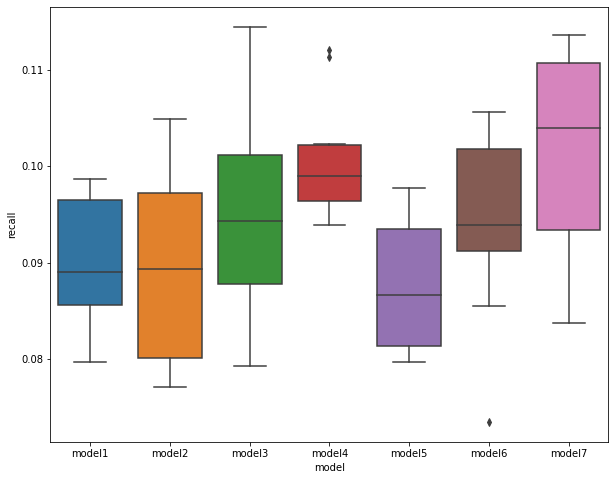

In [ ]:
fig = plt.figure(1, [10, 8])
ax = sns.boxplot(x="model", y="recall",
                 data=exp[(exp["k"]==5) & (exp["n_padded"]==10)])
plt.show()

In [ ]:
pvt10 = pd.pivot_table(exp[(exp["k"]==5)&(exp["n_padded"]==10)],
                     values=["recall"],
                     columns=["n_exp"],
                     index=["model"])
pvt10["mean"] = pvt10["recall"].mean(axis=1)
pvt10["std"] = pvt10["recall"].std(axis=1)
pvt10

recall                      ...                mean       std
n_exp          1         2         3  ...        10                    
model                                 ...                              
model1  0.089499  0.093229  0.088528  ...  0.098690  0.089968  0.006799
model2  0.079046  0.089001  0.077147  ...  0.098133  0.089224  0.009629
model3  0.091505  0.082305  0.097023  ...  0.102258  0.094427  0.010552
model4  0.111289  0.101764  0.100675  ...  0.093900  0.100817  0.006331
model5  0.097683  0.093564  0.090088  ...  0.080779  0.087764  0.007128
model6  0.097636  0.073472  0.085510  ...  0.090973  0.093910  0.009583
model7  0.091483  0.101594  0.112576  ...  0.113554  0.101310  0.011093

[7 rows x 12 columns]

In [ ]:
f_oneway(pvt10.values[0][:-2],
         pvt10.values[1][:-2],
         pvt10.values[2][:-2],
         pvt10.values[3][:-2],
         pvt10.values[4][:-2],
         pvt10.values[5][:-2],
         pvt10.values[6][:-2])

F_onewayResult(statistic=3.7346905458574975, pvalue=0.0030574364686785827)

In [ ]:
ttest_ind(pvt10.values[3][:-2], pvt10.values[1][:-2])

Ttest_indResult(statistic=3.1813882552962833, pvalue=0.005169646303146722)

## n_padded = 12 (recall)

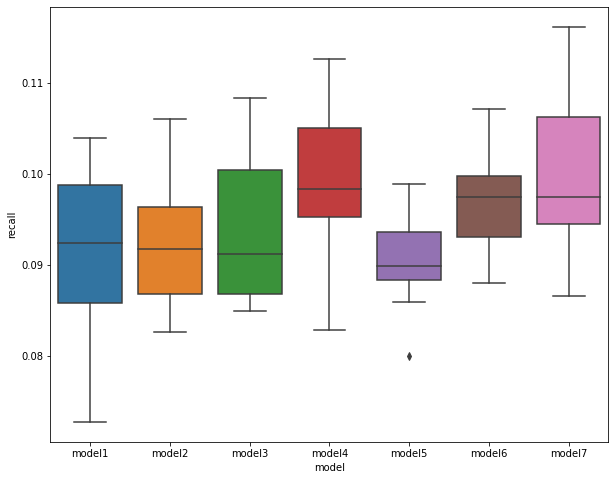

In [ ]:
fig = plt.figure(1, [10, 8])
ax = sns.boxplot(x="model", y="recall",
                 data=exp[(exp["k"]==5) & (exp["n_padded"]==12)])
plt.show()

In [ ]:
pvt12 = pd.pivot_table(exp[(exp["k"]==5)&(exp["n_padded"]==12)],
                     values=["recall"],
                     columns=["n_exp"],
                     index=["model"])
pvt12["mean"] = pvt12["recall"].mean(axis=1)
pvt12["std"] = pvt12["recall"].std(axis=1)
pvt12

recall                      ...                mean       std
n_exp          1         2         3  ...        10                    
model                                 ...                              
model1  0.103933  0.090616  0.072691  ...  0.099785  0.091621  0.009514
model2  0.093957  0.085038  0.102850  ...  0.093675  0.092576  0.007696
model3  0.086209  0.085149  0.097967  ...  0.092476  0.094273  0.009084
model4  0.111737  0.085348  0.095240  ...  0.100504  0.098974  0.010037
model5  0.090248  0.085866  0.089383  ...  0.098888  0.090659  0.005688
model6  0.091112  0.107171  0.087991  ...  0.098831  0.096674  0.005494
model7  0.095552  0.094070  0.116173  ...  0.086542  0.099566  0.009095

[7 rows x 12 columns]

In [ ]:
f_oneway(pvt12.values[0][:-2],
         pvt12.values[1][:-2],
         pvt12.values[2][:-2],
         pvt12.values[3][:-2],
         pvt12.values[4][:-2],
         pvt12.values[5][:-2],
         pvt12.values[6][:-2])

F_onewayResult(statistic=1.8546718250339926, pvalue=0.10278432673547877)

In [ ]:
ttest_ind(pvt12.values[3][:-2], pvt12.values[1][:-2])

Ttest_indResult(statistic=1.5995873853243274, pvalue=0.12709501107179644)